In [1]:
# Базовые библиотеки для воспроизводимости, работы с данными и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
import sentence_transformers
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


# Для retrieval-контура попробуем установить основные зависимости.
# Даже если sentence-transformers не поднимется, ноутбук сможет работать через fallback.
FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")


try:
    import faiss  # type: ignore
    FAISS_AVAILABLE = True
except Exception as e:
    FAISS_AVAILABLE = False
    print("FAISS недоступен, будет использован fallback на sklearn NearestNeighbors.")
    print("Причина:", repr(e))



print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS available:", FAISS_AVAILABLE)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

NumPy: 2.3.4
Pandas: 2.3.3
FAISS available: True
sentence-transformers доступен: True


In [2]:
print(f"Python: {sys.version.split()[0]}")
print(f"- faiss / faiss-cpu: {faiss.__version__}")
print(f"- sentence-transformers: {sentence_transformers.__version__}")

Python: 3.14.0
- faiss / faiss-cpu: 1.13.2
- sentence-transformers: 5.4.0


In [3]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


try:
    import torch

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

set_seed(19)

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


### База знаний и первичный анализ

In [4]:
docs_df = pd.read_csv("data/documents.csv", encoding="utf-8-sig")

# Выводим информацию
print("Размер корпуса:", len(docs_df))
docs_df.head()

Размер корпуса: 15


,doc_id,title,content
0,doc_01,Введение в Pandas,Pandas - это мощная библиотека Python для рабо...
1,doc_02,Работа с DataFrame,DataFrame - это двумерная структура данных в P...
2,doc_03,Чтение и запись данных,Pandas поддерживает множество форматов данных....
3,doc_04,Фильтрация данных,Фильтрация позволяет выбрать строки по условию...
4,doc_05,Группировка и агрегация,Группировка данных выполняется методом groupby...


In [5]:
documents = docs_df.to_dict(orient='records')

In [6]:
print("Примеры документов (первые 5):\n")
for idx, row in docs_df.head(5).iterrows():
    print(f"{'─'*65}")
    print(f"Документ {row['doc_id']}")
    print(f"Название: {row['title']}")
    print(f"Содержание:\n{row['content']}\n")
    print()

Примеры документов (первые 5):

─────────────────────────────────────────────────────────────────
Документ doc_01
Название: Введение в Pandas
Содержание:
Pandas - это мощная библиотека Python для работы с данными. 
Она предоставляет структуры данных DataFrame и Series для удобной обработки табличных данных.
Основные возможности Pandas: чтение данных из различных форматов (CSV, Excel, SQL),
очистка данных, фильтрация, группировка, агрегация и визуализация.
Для установки используйте команду: pip install pandas.
Импортируется библиотека как: import pandas as pd.


─────────────────────────────────────────────────────────────────
Документ doc_02
Название: Работа с DataFrame
Содержание:
DataFrame - это двумерная структура данных в Pandas, похожая на таблицу Excel.
Создание DataFrame: df = pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b', 'c']})
Основные методы: df.head() - первые 5 строк, df.info() - информация о столбцах,
df.describe() - статистика числовых столбцов, df.shape - размеры таблицы

Предметная область: Python и Pandas для анализа данных. Это совокупность справочных материалов, инструкций и практических примеров, охватывающих ключевые аспекты работы с данными.

По ней разумно строить retrieval / mini-RAG, поскольку:
- область обладает чёткой структурой
- тематика обеспечивает реалистичные сценарии использования
- масштаб базы знаний оптимален для учебного запуска

### Чанкинг документов

In [7]:
# Простая функция чанкинга по словам.
def chunk_text(text: str, chunk_size: int = 22, overlap: int = 5) -> List[str]:
    words = text.replace("\n", " ").split()

    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap

    for start in range(0, len(words), step):
        chunk_words = words[start : start + chunk_size]
        if not chunk_words:
            continue

        chunks.append(" ".join(chunk_words))

        if start + chunk_size >= len(words):
            break

    return chunks


def build_chunks_dataframe(
    docs: List[Dict[str, str]],
    chunk_size: int = 22,
    overlap: int = 5,
) -> pd.DataFrame:
    rows = []

    for doc in docs:
        chunks = chunk_text(doc["content"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": chunk_id,
                    "chunk_text": chunk,
                    "n_words": len(chunk.split()),
                }
            )

    return pd.DataFrame(rows)


chunks_df = build_chunks_dataframe(documents, chunk_size=20, overlap=5)

print("Количество чанков:", len(chunks_df))
display(chunks_df.head(10))

Количество чанков: 46


,doc_id,title,chunk_id,chunk_text,n_words
0,doc_01,Введение в Pandas,0,Pandas - это мощная библиотека Python для рабо...,20
1,doc_01,Введение в Pandas,1,и Series для удобной обработки табличных данны...,20
2,doc_01,Введение в Pandas,2,"(CSV, Excel, SQL), очистка данных, фильтрация,...",20
3,doc_01,Введение в Pandas,3,install pandas. Импортируется библиотека как: ...,9
4,doc_02,Работа с DataFrame,0,DataFrame - это двумерная структура данных в P...,20
5,doc_02,Работа с DataFrame,1,"= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b'...",20
6,doc_02,Работа с DataFrame,2,"строк, df.info() - информация о столбцах, df.d...",20
7,doc_02,Работа с DataFrame,3,Для доступа к столбцу используйте: df['column_...,8
8,doc_03,Чтение и запись данных,0,Pandas поддерживает множество форматов данных....,20
9,doc_03,Чтение и запись данных,1,"= pd.read_excel('file.xlsx', sheet_name='Sheet...",20


Выбраны параметры chunk_size=20, overlap=5, поскольку при таком chunk_size чанкинг даёт в результате 46 чанков, что удовлетворяет требованиям дз.

### Эмбеддинги и индекс FAISS

In [8]:
# Единый интерфейс для двух вариантов векторизации: dense embeddings и fallback.
class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfFallbackBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2), lowercase=True)
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray()
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray()
        return vectors.astype("float32")


def build_embedding_backend(
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device: str = "cpu",
) -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(model_name=model_name, device=device)
        print("Используем полноценные dense embeddings.")
        print("Бэкэнд:", backend.backend_name)
        return backend
    except Exception as e:
        print("Не удалось загрузить sentence-transformers encoder.")
        print("Причина:", repr(e))
        print("Переключаемся на TF-IDF fallback. Ноутбук останется рабочим,")
        print("но это уже не полноценные dense embeddings.")
        return TfidfFallbackBackend()


embedder = build_embedding_backend(device=DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем полноценные dense embeddings.
Бэкэнд: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [9]:
# Строим векторные представления для всех чанков.
chunk_texts = chunks_df["chunk_text"].tolist()
chunk_embeddings = embedder.fit_documents(chunk_texts)

print("Форма матрицы эмбеддингов:", chunk_embeddings.shape)

# Проверяем длины векторов.
# Если normalize_embeddings=True сработал корректно, все нормы должны быть ≈ 1.0.
# Это означает, что косинусное сходство далее можно считать через скалярное произведение.
vector_norms = np.linalg.norm(chunk_embeddings, axis=1)
print("Минимальная норма:", round(float(vector_norms.min()), 4))
print("Максимальная норма:", round(float(vector_norms.max()), 4))
print("Средняя норма:", round(float(vector_norms.mean()), 4))
print("→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.")

Форма матрицы эмбеддингов: (46, 384)
Минимальная норма: 1.0
Максимальная норма: 1.0
Средняя норма: 1.0
→ Нормы ≈ 1.0: нормировка подтверждена, dot product = cosine similarity.


In [10]:
# Единая обёртка над FAISS и fallback-поиском.
class VectorSearchIndex:
    def __init__(self, dim: int) -> None:
        self.dim = dim
        self.backend_name = None
        self._faiss_index = None
        self._nn_index = None

        if FAISS_AVAILABLE:
            self._faiss_index = faiss.IndexFlatIP(dim)  # type: ignore[name-defined]
            self.backend_name = "FAISS IndexFlatIP"
        else:
            self._nn_index = NearestNeighbors(metric="cosine")
            self.backend_name = "sklearn NearestNeighbors fallback"

    def add(self, vectors: np.ndarray) -> None:
        vectors = vectors.astype("float32")

        if self._faiss_index is not None:
            self._faiss_index.add(vectors)
        else:
            self._nn_index.fit(vectors)

    def search(self, query_vectors: np.ndarray, top_k: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        query_vectors = query_vectors.astype("float32")

        if self._faiss_index is not None:
            scores, indices = self._faiss_index.search(query_vectors, top_k)
            return scores, indices

        distances, indices = self._nn_index.kneighbors(query_vectors, n_neighbors=top_k)
        scores = 1.0 - distances
        return scores, indices


search_index = VectorSearchIndex(dim=chunk_embeddings.shape[1])
search_index.add(chunk_embeddings)

print("Индекс построен.")
print("Бэкэнд индекса:", search_index.backend_name)


Индекс построен.
Бэкэнд индекса: FAISS IndexFlatIP


In [11]:
# Удобная функция для поиска похожих чанков.
def search_similar_chunks(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vectors = embedder.encode_queries([query])
    scores, indices = search_index.search(query_vectors, top_k=top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": int(chunk_row["chunk_id"]),
                "score": round(float(score), 4),
                "chunk_text": chunk_row["chunk_text"],
            }
        )

    return pd.DataFrame(rows)


# Проверяем FAISS-поиск на первом запросе.
# Результаты должны совпасть с ручным расчётом из секции 6:
# тот же top-k, те же фрагменты, те же оценки сходства.
faiss_queries = [
    "Как прочитать CSV файл в pandas?",
    "Как создать DataFrame и посмотреть первые строки?",
    "Как обработать пропущенные значения NaN?",
    "Как объединить две таблицы по общему столбцу?",
    "В чем разница между merge и concat?"]

for query in faiss_queries:
    faiss_results_df = search_similar_chunks(query, top_k=5)
    display(Markdown(f"**Запрос:** {query}"))
    display(faiss_results_df)

**Запрос:** Как прочитать CSV файл в pandas?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_03,Чтение и запись данных,0,0.8140,Pandas поддерживает множество форматов данных....
1,2,doc_14,Экспорт данных,0,0.7363,Pandas поддерживает экспорт в различные формат...
2,3,doc_01,Введение в Pandas,1,0.6831,и Series для удобной обработки табличных данны...
3,4,doc_01,Введение в Pandas,3,0.6674,install pandas. Импортируется библиотека как: ...
4,5,doc_01,Введение в Pandas,2,0.6569,"(CSV, Excel, SQL), очистка данных, фильтрация,..."


**Запрос:** Как создать DataFrame и посмотреть первые строки?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_02,Работа с DataFrame,1,0.6940,"= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b'..."
1,2,doc_02,Работа с DataFrame,0,0.6436,DataFrame - это двумерная структура данных в P...
2,3,doc_02,Работа с DataFrame,2,0.5469,"строк, df.info() - информация о столбцах, df.d..."
3,4,doc_08,Визуализация с Matplotlib,0,0.4825,Matplotlib - основная библиотека для визуализа...
4,5,doc_15,Оптимизация работы с большими данными,2,0.4769,Использование Dask для очень больших данных: i...


**Запрос:** Как обработать пропущенные значения NaN?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_06,Обработка пропущенных значений,0,0.7657,Пропущенные значения (NaN) требуют специальной...
1,2,doc_07,NumPy основы,2,0.4498,"10, 2) Случайные числа: np.random.rand(5), np...."
2,3,doc_03,Чтение и запись данных,2,0.4480,"= pd.read_sql_query('SELECT * FROM table', con..."
3,4,doc_07,NumPy основы,1,0.4388,"4, 5]) Матрица: matrix = np.array([[1, 2], [3,..."
4,5,doc_07,NumPy основы,0,0.3367,NumPy - библиотека для работы с многомерными м...


**Запрос:** Как объединить две таблицы по общему столбцу?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_10,Объединение таблиц,0,0.5390,Для объединения таблиц используются методы mer...
1,2,doc_08,Визуализация с Matplotlib,2,0.5378,"plt.xlabel('X'), plt.ylabel('Y') Несколько гра..."
2,3,doc_02,Работа с DataFrame,2,0.4553,"строк, df.info() - информация о столбцах, df.d..."
3,4,doc_10,Объединение таблиц,2,0.4126,"pd.concat([df1, df2], axis=0) - добавление стр..."
4,5,doc_02,Работа с DataFrame,0,0.4052,DataFrame - это двумерная структура данных в P...


**Запрос:** В чем разница между merge и concat?

,rank,doc_id,title,chunk_id,score,chunk_text
0,1,doc_10,Объединение таблиц,1,0.5419,"Типы join: 'inner', 'outer', 'left', 'right' О..."
1,2,doc_10,Объединение таблиц,0,0.5083,Для объединения таблиц используются методы mer...
2,3,doc_10,Объединение таблиц,2,0.4869,"pd.concat([df1, df2], axis=0) - добавление стр..."
3,4,doc_13,Работа с датами и временем,2,0.2879,freq='D') Resample (агрегация по времени): df....
4,5,doc_15,Оптимизация работы с большими данными,1,0.2873,'col2']) Оптимизация типов: df['col'] = df['co...


### Контрольные запросы и оценка retrieval

In [12]:
# Набор контрольных запросов и ожидаемых релевантных документов.
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Как прочитать CSV файл в pandas?",
        "relevant_doc_ids": ["doc_03"],  # Чтение и запись данных
    },
    {
        "query_id": "q02",
        "query": "Как удалить пропущенные значения NaN?",
        "relevant_doc_ids": ["doc_06"],  # Обработка пропусков
    },
    {
        "query_id": "q03",
        "query": "Как сгруппировать данные и посчитать среднее?",
        "relevant_doc_ids": ["doc_05"],  # Группировка и агрегация
    },
    {
        "query_id": "q04",
        "query": "Как объединить две таблицы по общему столбцу?",
        "relevant_doc_ids": ["doc_10"],  # Объединение таблиц
    },
    {
        "query_id": "q05",
        "query": "Как отсортировать DataFrame по значению столбца?",
        "relevant_doc_ids": ["doc_11"],  # Сортировка данных
    },
    {
        "query_id": "q06",
        "query": "Как применить функцию к каждому элементу столбца?",
        "relevant_doc_ids": ["doc_12"],  # Применение функций
    },
    {
        "query_id": "q07",
        "query": "Как работать с датами и извлекать год/месяц?",
        "relevant_doc_ids": ["doc_13"],  # Работа с датами
    },
    {
        "query_id": "q08",
        "query": "Как построить гистограмму или scatter plot?",
        "relevant_doc_ids": ["doc_08", "doc_09"],  # Визуализация
    },
    {
        "query_id": "q09",
        "query": "Как создать DataFrame из словаря и посмотреть первые строки?",
        "relevant_doc_ids": ["doc_02"],  # Работа с DataFrame
    },
    {
        "query_id": "q10",
        "query": "Как отфильтровать строки по нескольким условиям?",
        "relevant_doc_ids": ["doc_04"],  # Фильтрация данных
    },
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,Как прочитать CSV файл в pandas?,[doc_03]
1,q02,Как удалить пропущенные значения NaN?,[doc_06]
2,q03,Как сгруппировать данные и посчитать среднее?,[doc_05]
3,q04,Как объединить две таблицы по общему столбцу?,[doc_10]
4,q05,Как отсортировать DataFrame по значению столбца?,[doc_11]
5,q06,Как применить функцию к каждому элементу столбца?,[doc_12]
6,q07,Как работать с датами и извлекать год/месяц?,[doc_13]
7,q08,Как построить гистограмму или scatter plot?,"[doc_08, doc_09]"
8,q09,Как создать DataFrame из словаря и посмотреть ...,[doc_02]
9,q10,Как отфильтровать строки по нескольким условиям?,[doc_04]


In [13]:
# В этом разделе собираем self-contained реализацию:
# чанкинг -> векторизация -> индекс -> поиск -> оценка.

def chunk_text(text: str, chunk_size: int = 40, overlap: int = 10) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore

        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
        return vectors.astype("float32")


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF fallback"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.fit_transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.vectorizer.transform(texts).toarray().astype("float32")
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


def select_backend(device: str = "cpu") -> EmbeddingBackend:
    try:
        backend = SentenceTransformersBackend(
            model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
            device=device,
        )
        print("Используем dense-модель эмбеддингов.")
        return backend
    except Exception as e:
        print("Dense-модель недоступна, переключаемся на fallback.")
        print("Причина:", repr(e))
        return TfidfBackend()


def build_chunks(
    docs: List[Dict[str, str]],
    chunk_size: int,
    overlap: int,
) -> List[Dict[str, object]]:
    rows: List[Dict[str, object]] = []
    for doc in docs:
        parts = chunk_text(doc["content"], chunk_size=chunk_size, overlap=overlap)
        for chunk_idx, chunk_text_value in enumerate(parts):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f"{doc['doc_id']}_chunk_{chunk_idx}",
                    "chunk_idx": chunk_idx,
                    "chunk_text": chunk_text_value,
                }
            )
    return rows


@dataclass
class RetrievalArtifacts:
    backend_name: str
    backend: EmbeddingBackend
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    index: object


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 40,
    overlap: int = 10,
    device: str = "cpu",
) -> RetrievalArtifacts:
    chunks = build_chunks(docs, chunk_size=chunk_size, overlap=overlap)
    chunks_df = pd.DataFrame(chunks)

    backend = select_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist())

    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS недоступен. Для этого ноутбука ожидается установленный faiss-cpu.")

    index = faiss.IndexFlatIP(chunk_vectors.shape[1])
    index.add(chunk_vectors)

    return RetrievalArtifacts(
        backend_name=backend.backend_name,
        backend=backend,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        index=index,
    )


def search_chunks(
    query: str,
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype("float32")
    scores, indices = artifacts.index.search(query_vector, top_k)

    rows = []
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), start=1):
        chunk_row = artifacts.chunks_df.iloc[int(idx)]
        rows.append(
            {
                "rank": rank,
                "score": float(score),
                "doc_id": chunk_row["doc_id"],
                "title": chunk_row["title"],
                "chunk_id": chunk_row["chunk_id"],
                "chunk_text": chunk_row["chunk_text"],
            }
        )
    return pd.DataFrame(rows)


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered


def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    # Расчёт recall@k: доля релевантных документов, попавших в топ-k результатов
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }


def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrievalArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [14]:
# Собираем baseline-конфигурацию retriever.
baseline_chunk_size = 20
baseline_overlap = 5

artifacts = build_retriever(
    documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


In [15]:
print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

for q_dict in benchmark_queries:
    query_text = q_dict["query"]
    display(Markdown(f"### Запрос: {query_text}"))
    display(search_chunks(query_text, artifacts=artifacts, top_k=5)[["rank", "score", "doc_id", "title", "chunk_text"]])

Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 46


,doc_id,title,chunk_id,chunk_idx,chunk_text
0,doc_01,Введение в Pandas,doc_01_chunk_0,0,Pandas - это мощная библиотека Python для рабо...
1,doc_01,Введение в Pandas,doc_01_chunk_1,1,и Series для удобной обработки табличных данны...
2,doc_01,Введение в Pandas,doc_01_chunk_2,2,"(CSV, Excel, SQL), очистка данных, фильтрация,..."
3,doc_01,Введение в Pandas,doc_01_chunk_3,3,install pandas. Импортируется библиотека как: ...
4,doc_02,Работа с DataFrame,doc_02_chunk_0,0,DataFrame - это двумерная структура данных в P...


### Запрос: Как прочитать CSV файл в pandas?

,rank,score,doc_id,title,chunk_text
0,1,0.813964,doc_03,Чтение и запись данных,Pandas поддерживает множество форматов данных....
1,2,0.736319,doc_14,Экспорт данных,Pandas поддерживает экспорт в различные формат...
2,3,0.683103,doc_01,Введение в Pandas,и Series для удобной обработки табличных данны...
3,4,0.667400,doc_01,Введение в Pandas,install pandas. Импортируется библиотека как: ...
4,5,0.656935,doc_01,Введение в Pandas,"(CSV, Excel, SQL), очистка данных, фильтрация,..."


### Запрос: Как удалить пропущенные значения NaN?

...

,rank,score,doc_id,title,chunk_text
0,1,0.674375,doc_09,Визуализация с Seaborn,"sns.histplot(data, kde=True) Box plot: sns.box..."
1,2,0.635813,doc_08,Визуализация с Matplotlib,"marker='o', linestyle='-', color='blue') Точеч..."
2,3,0.633199,doc_08,Визуализация с Matplotlib,Matplotlib - основная библиотека для визуализа...
3,4,0.608061,doc_08,Визуализация с Matplotlib,"plt.xlabel('X'), plt.ylabel('Y') Несколько гра..."
4,5,0.600801,doc_09,Визуализация с Seaborn,"sns.heatmap(df.corr(), annot=True, cmap='coolw..."


### Запрос: Как создать DataFrame из словаря и посмотреть первые строки?

,rank,score,doc_id,title,chunk_text
0,1,0.658363,doc_02,Работа с DataFrame,"= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b'..."
1,2,0.604528,doc_02,Работа с DataFrame,DataFrame - это двумерная структура данных в P...
2,3,0.543194,doc_02,Работа с DataFrame,"строк, df.info() - информация о столбцах, df.d..."
3,4,0.472660,doc_01,Введение в Pandas,Pandas - это мощная библиотека Python для рабо...
4,5,0.438068,doc_01,Введение в Pandas,и Series для удобной обработки табличных данны...


### Запрос: Как отфильтровать строки по нескольким условиям?

,rank,score,doc_id,title,chunk_text
0,1,0.455470,doc_04,Фильтрация данных,Фильтрация позволяет выбрать строки по условию...
1,2,0.395583,doc_06,Обработка пропущенных значений,пропусков: df.dropna() - удаляет строки с проп...
2,3,0.392792,doc_02,Работа с DataFrame,"= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b'..."
3,4,0.391020,doc_06,Обработка пропущенных значений,Пропущенные значения (NaN) требуют специальной...
4,5,0.375558,doc_10,Объединение таблиц,"pd.concat([df1, df2], axis=0) - добавление стр..."


In [16]:
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Как прочитать CSV файл в pandas?,doc_03,"doc_03, doc_14, doc_01",1,1.0,1.0,1.0
1,q02,Как удалить пропущенные значения NaN?,doc_06,"doc_06, doc_03, doc_07",1,1.0,1.0,1.0
2,q03,Как сгруппировать данные и посчитать среднее?,doc_05,"doc_05, doc_02",1,1.0,1.0,1.0
3,q04,Как объединить две таблицы по общему столбцу?,doc_10,"doc_10, doc_08, doc_02",1,1.0,1.0,1.0
4,q05,Как отсортировать DataFrame по значению столбца?,doc_11,doc_02,0,0.0,0.0,NaN
5,q06,Как применить функцию к каждому элементу столбца?,doc_12,"doc_02, doc_12, doc_07",1,1.0,0.5,2.0
6,q07,Как работать с датами и извлекать год/месяц?,doc_13,"doc_13, doc_05",1,1.0,1.0,1.0
7,q08,Как построить гистограмму или scatter plot?,"doc_08, doc_09","doc_09, doc_08",1,1.0,1.0,1.0
8,q09,Как создать DataFrame из словаря и посмотреть ...,doc_02,doc_02,1,1.0,1.0,1.0
9,q10,Как отфильтровать строки по нескольким условиям?,doc_04,"doc_04, doc_06, doc_02",1,1.0,1.0,1.0


,metric,value
0,mean_hit@3,0.90
1,mean_recall@3,0.90
2,mean_MRR@3,0.85


In [17]:
cols_to_keep = ["query", "relevant_doc_ids", "predicted_doc_ids", "hit@3", "recall@3"]
retrieval_eval_df = baseline_eval_k3[cols_to_keep].copy()

# 2. Переименовываем столбцы в требуемый формат
retrieval_eval_df = retrieval_eval_df.rename(columns={
    "relevant_doc_ids": "expected_source",
    "predicted_doc_ids": "retrieved_sources",
    "hit@3": "hit_at_k",
    "recall@3": "recall_at_k"
})

# 3. Сохраняем в CSV
# encoding="utf-8-sig" нужен, чтобы Excel корректно открывал кириллицу
output_file = "artifacts/retrieval_eval.csv"
retrieval_eval_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Файл '{output_file}' успешно сохранен.")

Файл 'artifacts/retrieval_eval.csv' успешно сохранен.


### Небольшой эксперимент с параметрами retrieval

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,20,5,46,SentenceTransformer: sentence-transformers/par...,0.9,0.9,0.85
1,40,5,25,SentenceTransformer: sentence-transformers/par...,0.8,0.8,0.70


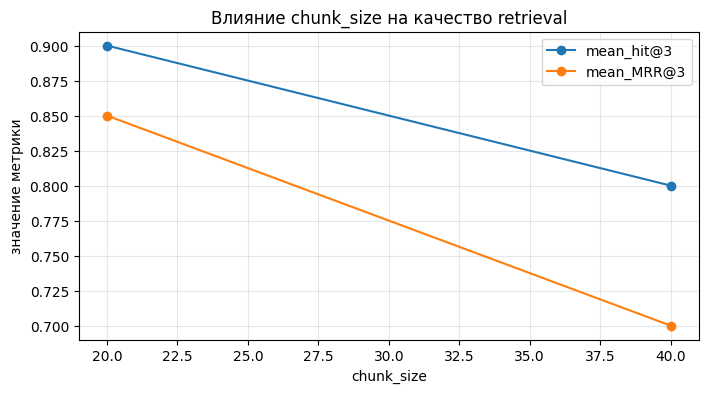

In [18]:
# Сравниваем несколько конфигураций чанкинга.
chunksize_configs = [20, 40]

chunk_experiments = []

for cfg in chunksize_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg,
        overlap=5,
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg,
            "overlap": 5,
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Обновление базы знаний и переиндексация

In [19]:
new_docs = [
    {
        "doc_id": "doc_16",
        "title": "Векторизованные операции vs циклы в Pandas",
        "content": """Избегайте циклов for при обработке DataFrame. Используйте векторизованные методы.
        Вместо df.apply(lambda x: x*2) лучше df['col'] * 2.
        Для сложных условий используйте np.where() или df.loc[условие, 'col'] = значение.
        Векторизация ускоряет код в 10-100 раз за счёт оптимизаций C/NumPy под капотом."""
    },
    {
        "doc_id": "doc_17",
        "title": "Оптимизация памяти и типы данных",
        "content": """Снижайте потребление памяти через оптимизацию dtypes.
        Используйте category для строк с малым числом уникальных значений: df['col'] = df['col'].astype('category').
        Понижайте разрядность чисел: float64 -> float32, int64 -> int32/int8.
        Метод df.info(memory_usage='deep') покажет реальное потребление памяти."""
    },
    {
        "doc_id": "doc_18",
        "title": "Seaborn vs Matplotlib: когда что выбрать?",
        "content": """Matplotlib — низкоуровневая библиотека, даёт полный контроль над осями и элементами.
        Seaborn — высокоуровневая обёртка, автоматически рисует статистические графики (boxplot, pairplot, heatmap).
        Используйте Seaborn для быстрого EDA и Matplotlib для кастомных публикационных графиков.
        Они совместимы: fig, ax = plt.subplots(); sns.scatterplot(..., ax=ax)."""
    }
]

# Обновляем общий список документов
upd_documents = documents + new_docs
print(f"Размер корпуса после обновления: {len(upd_documents)}")

Размер корпуса после обновления: 18


In [20]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    upd_documents,
    chunk_size=baseline_chunk_size,
    overlap=baseline_overlap,
    device=DEVICE,
)

before_update_eval = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используем dense-модель эмбеддингов.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Как прочитать CSV файл в pandas?,doc_03,"doc_03, doc_14, doc_01",1,1.0,1.0,1.0,"doc_03, doc_14, doc_01",1,1.0,1.0,1.0
1,q02,Как удалить пропущенные значения NaN?,doc_06,"doc_06, doc_03, doc_07",1,1.0,1.0,1.0,"doc_06, doc_03, doc_07",1,1.0,1.0,1.0
2,q03,Как сгруппировать данные и посчитать среднее?,doc_05,"doc_05, doc_02",1,1.0,1.0,1.0,"doc_05, doc_02",1,1.0,1.0,1.0
3,q04,Как объединить две таблицы по общему столбцу?,doc_10,"doc_10, doc_08, doc_02",1,1.0,1.0,1.0,"doc_10, doc_08, doc_02",1,1.0,1.0,1.0
4,q05,Как отсортировать DataFrame по значению столбца?,doc_11,doc_02,0,0.0,0.0,NaN,doc_02,0,0.0,0.0,NaN
5,q06,Как применить функцию к каждому элементу столбца?,doc_12,"doc_02, doc_12, doc_07",1,1.0,0.5,2.0,"doc_02, doc_12, doc_07",1,1.0,0.5,2.0
6,q07,Как работать с датами и извлекать год/месяц?,doc_13,"doc_13, doc_05",1,1.0,1.0,1.0,"doc_13, doc_05",1,1.0,1.0,1.0
7,q08,Как построить гистограмму или scatter plot?,"doc_08, doc_09","doc_09, doc_08",1,1.0,1.0,1.0,"doc_09, doc_08, doc_18",1,1.0,1.0,1.0
8,q09,Как создать DataFrame из словаря и посмотреть ...,doc_02,doc_02,1,1.0,1.0,1.0,doc_02,1,1.0,1.0,1.0
9,q10,Как отфильтровать строки по нескольким условиям?,doc_04,"doc_04, doc_06, doc_02",1,1.0,1.0,1.0,"doc_04, doc_17, doc_06",1,1.0,1.0,1.0


In [21]:
summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

,metric,before_update,after_update,delta
0,mean_hit@3,0.90,0.90,0.0
1,mean_recall@3,0.90,0.90,0.0
2,mean_MRR@3,0.85,0.85,0.0


In [22]:
result_df = comparison_df.rename(columns={
    'predicted_doc_ids_before': 'before_retrieved_sources',
    'predicted_doc_ids_after': 'after_retrieved_sources'
})[['query', 'before_retrieved_sources', 'after_retrieved_sources']]

result_df['changed'] = result_df['before_retrieved_sources'] != result_df['after_retrieved_sources']

output_file = 'artifacts/retrieval_before_after_update.csv'
result_df.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"Файл '{output_file}' сохранен ({len(result_df)} записей)")

Файл 'artifacts/retrieval_before_after_update.csv' сохранен (10 записей)


### Mini-RAG

In [23]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [24]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [25]:
query = "Что делать, если в данных есть пропуски?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Что делать, если в данных есть пропуски?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.520529,doc_06,Обработка пропущенных значений,doc_06_chunk_0,Пропущенные значения (NaN) требуют специальной...
1,2,0.450703,doc_03,Чтение и запись данных,doc_03_chunk_1,"= pd.read_excel('file.xlsx', sheet_name='Sheet..."
2,3,0.434463,doc_02,Работа с DataFrame,doc_02_chunk_1,"= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b'..."


[Источник: doc_06 | Обработка пропущенных значений | score=0.5205]
Пропущенные значения (NaN) требуют специальной обработки. Поиск пропусков: df.isnull().sum() - количество пропусков по столбцам Удаление пропусков: df.dropna() - удаляет строки

[Источник: doc_03 | Чтение и запись данных | score=0.4507]
= pd.read_excel('file.xlsx', sheet_name='Sheet1') Запись CSV: df.to_csv('output.csv', index=False) Запись Excel: df.to_excel('output.xlsx', index=False) Чтение из SQL: df = pd.read_sql_query('SELECT * FROM table',

[Источник: doc_02 | Работа с DataFrame | score=0.4345]
= pd.DataFrame({'A': [1, 2, 3], 'B': ['a', 'b', 'c']}) Основные методы: df.head() - первые 5 строк, df.info() - информация о


In [26]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [27]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["content"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["content"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [28]:
rag_result = mini_rag_answer(
    "Как прочитать CSV файл?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Как прочитать CSV файл?

**Ответ:** Чтение CSV: df = pd.read_csv('file.csv', sep=',', encoding='utf-8') Чтение Excel: df = pd.read_excel('file.xlsx', sheet_name='Sheet1') Запись CSV: Чтение частями: pd.read_csv('large.csv', chunksize=10000) Выбор столбцов: pd.read_csv('file.csv', usecols=['col1', 'col2']) Оптимизация типов: df['col'] =

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.591891,doc_03,Чтение и запись данных,doc_03_chunk_0,Pandas поддерживает множество форматов данных....
1,2,0.560399,doc_03,Чтение и запись данных,doc_03_chunk_1,"= pd.read_excel('file.xlsx', sheet_name='Sheet..."
2,3,0.560316,doc_15,Оптимизация работы с большими данными,doc_15_chunk_0,Для работы с большими данными используйте опти...


### Краткий анализ ошибок

In [29]:
def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

In [30]:
evaluation_df = evaluate_mini_rag(benchmark_queries[:5], artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,rag_answer
0,q01,Как прочитать CSV файл в pandas?,doc_03,"doc_03, doc_14, doc_01",1,"Чтение CSV: df = pd.read_csv('file.csv', sep='..."
1,q02,Как удалить пропущенные значения NaN?,doc_06,"doc_06, doc_03, doc_07",1,Пропущенные значения (NaN) требуют специальной...
2,q03,Как сгруппировать данные и посчитать среднее?,doc_05,"doc_05, doc_05, doc_02",1,В найденном контексте нет достаточно релевантн...
3,q04,Как объединить две таблицы по общему столбцу?,doc_10,"doc_10, doc_08, doc_02",1,"Для доступа к столбцу используйте: строк, df.i..."
4,q05,Как отсортировать DataFrame по значению столбца?,doc_11,"doc_02, doc_02, doc_02",0,Создание DataFrame: df = pd.DataFrame({'A': [1...


В результате работы mini-RAG выявлено два неудачных случая:
- на запрос "Как сгруппировать данные и посчитать среднее?" не удалось найти ответ. Проблема может заключаться в том, что в "релевантном" документе не упоминается функция avg().
- на запрос "Как отсортировать DataFrame по значению столбца?" найденный ответ не является релевантным, подобран не тот документ.

In [31]:
rag_examples_df = evaluation_df.rename(columns={
    "query": "question",           
    "rag_answer": "answer",       
    "predicted_doc_ids": "retrieved_sources"
})[["question", "answer", "retrieved_sources"]]

output_file = "artifacts/rag_examples.csv"
rag_examples_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Файл '{output_file}' успешно сохранен ({len(rag_examples_df)} примеров)")

Файл 'artifacts/rag_examples.csv' успешно сохранен (5 примеров)
